## Relaciones, segmentación y detección de anomalías

En esta etapa del proyecto se profundiza el análisis exploratorio de los datos mediante el estudio de relaciones entre variables, la segmentación de vehículos y la identificación de valores atípicos. El objetivo es comprender con mayor detalle los factores que influyen en el precio de los vehículos usados y detectar patrones relevantes presentes en la base AutoTec.

Se aplica una metodología de detección de anomalías basada en el rango intercuartílico (IQR), con el propósito de identificar vehículos cuyos precios presentan comportamientos significativamente distintos al resto de la muestra. Este análisis permite reconocer segmentos específicos del mercado, como modelos de alta gama o vehículos con características particulares que influyen en su valorización.

In [1]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from dotenv import load_dotenv

from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, regexp_extract, when, lit, udf, regexp_replace,
    lower, trim, translate, initcap, split,
    current_date, year as spark_year, count, round as spark_round, avg, desc
)
from pyspark.sql.types import FloatType, StringType, IntegerType

def formato_chileno(valor):
    try:
        return f"{float(valor):,.0f}".replace(",", ".")
    except:
        return valor

def formato_pesos_eje():
    plt.gca().yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, pos: f"${x:,.0f}".replace(",", "."))
    )

In [2]:
load_dotenv()

MONGO_URI = os.getenv("MONGO_URI")

if MONGO_URI is None:
    raise ValueError("No se encontró la variable MONGO_URI en el archivo .env")

spark = (
    SparkSession.builder
    .appName("EDA_Graficos_Relaciones")
    .config("spark.mongodb.read.connection.uri", MONGO_URI)
    .config("spark.mongodb.write.connection.uri", MONGO_URI)
    .config("spark.jars.packages", "org.mongodb.spark:mongo-spark-connector_2.12:10.1.1")
    .getOrCreate()
)

df = (
    spark.read.format("mongodb")
    .option("database", "proyecto_bigdata")
    .option("collection", "Contenedor_Autos_Limpio")
    .load()
)

print("Cantidad de registros cargados:", df.count())
df.printSchema()

Cantidad de registros cargados: 1988
root
 |-- _id: string (nullable = true)
 |-- antiguedad_auto: integer (nullable = true)
 |-- cat_combustible: integer (nullable = true)
 |-- categoria_precio: string (nullable = true)
 |-- ciudad: string (nullable = true)
 |-- combustible: string (nullable = true)
 |-- es_ecologico: integer (nullable = true)
 |-- fecha_captura: string (nullable = true)
 |-- foto_url: string (nullable = true)
 |-- grupo: string (nullable = true)
 |-- kilometraje: double (nullable = true)
 |-- marca: string (nullable = true)
 |-- modelo: string (nullable = true)
 |-- precio: double (nullable = true)
 |-- rango_kilometraje: string (nullable = true)
 |-- tipo_marca: string (nullable = true)
 |-- url: string (nullable = true)
 |-- uso_anual_estimado: double (nullable = true)
 |-- usuario: string (nullable = true)
 |-- year: integer (nullable = true)



In [3]:
df_eda = df.select(
    "marca",
    "modelo",
    "precio",
    "kilometraje",
    "year",
    "combustible",
    "ciudad",
    "cat_combustible",
    "antiguedad_auto", 
    "uso_anual_estimado",
    "es_ecologico",
    "categoria_precio",
    "rango_kilometraje",
    "tipo_marca")

df_eda = df_eda.withColumn(
    "segmento_depreciacion",
    when((col("antiguedad_auto") <= 3) & (col("kilometraje") < 50000), "baja depreciacion")
    .when((col("antiguedad_auto") <= 8) & (col("kilometraje") < 120000), "depreciacion media")
    .otherwise("alta depreciacion")
)
print("Registros disponibles para EDA multivariado:", df_eda.count())
df_eda.show(10, truncate=False)

Registros disponibles para EDA multivariado: 1988
+-----+----------------------------+-------+-----------+----+-----------+--------+---------------+---------------+------------------+------------+----------------+-----------------+----------+---------------------+
|marca|modelo                      |precio |kilometraje|year|combustible|ciudad  |cat_combustible|antiguedad_auto|uso_anual_estimado|es_ecologico|categoria_precio|rango_kilometraje|tipo_marca|segmento_depreciacion|
+-----+----------------------------+-------+-----------+----+-----------+--------+---------------+---------------+------------------+------------+----------------+-----------------+----------+---------------------+
|audi |A1 Sportback 30 Tfsi Sport  |2.199E7|27294.0    |2024|bencina    |santiago|0              |2              |13647.0           |0           |Alto            |Bajo             |premium   |baja depreciacion    |
|audi |A1 Sportback 30 Tfsi Sport  |2.199E7|11766.0    |2024|bencina    |santiago|0       

In [4]:
df_categoria = (
    df_eda.groupBy("categoria_precio")
    .agg(
        count("*").alias("cantidad"),
        spark_round(avg("precio"), 0).alias("precio_promedio"),
        spark_round(avg("kilometraje"), 0).alias("kilometraje_promedio"),
        spark_round(avg("antiguedad_auto"), 0).alias("antiguedad_promedio")
    )
    .orderBy("precio_promedio")
)

categoria_pd = df_categoria.toPandas()

for c in categoria_pd.columns:
    if c != "categoria_precio":
        categoria_pd[c] = categoria_pd[c].apply(formato_chileno)

categoria_pd

,categoria_precio,cantidad,precio_promedio,kilometraje_promedio,antiguedad_promedio
0,bajo,482,8.072.901,92.609,6
1,medio,1.054,14.259.945,66.742,4
2,alto,348,25.474.971,63.266,4
3,premium,104,47.282.500,41.210,3


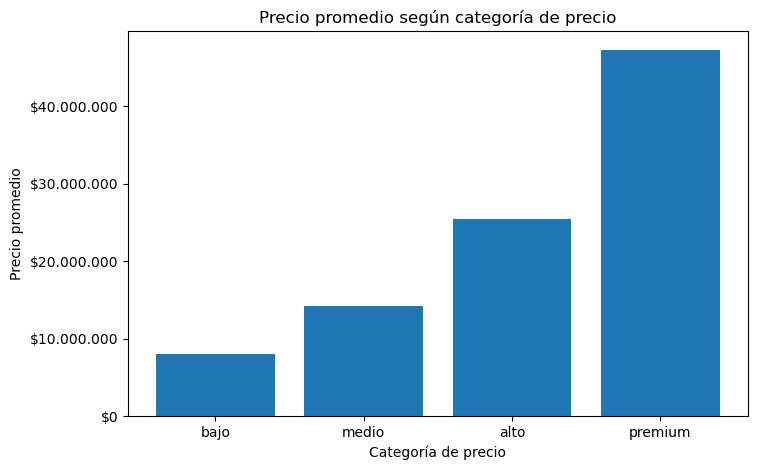

In [5]:
categoria_grafico = df_categoria.toPandas()

plt.figure(figsize=(8, 5))

plt.bar(
    categoria_grafico["categoria_precio"],
    categoria_grafico["precio_promedio"]
)

plt.title("Precio promedio según categoría de precio")
plt.xlabel("Categoría de precio")
plt.ylabel("Precio promedio")
formato_pesos_eje()

plt.show()

## Interpretación de la categoría de precio

La clasificación por categorías permite segmentar los vehículos según su valor de mercado. Se observa una diferencia progresiva entre los grupos bajo, medio, alto y premium, lo que demuestra que la segmentación construida representa adecuadamente distintos niveles de precio dentro de la base de datos.

Esta variable será útil en análisis posteriores, ya que permite comparar comportamientos entre grupos de vehículos con características económicas similares.

In [6]:
df_rango = (
    df_eda.groupBy("rango_kilometraje")
    .agg(
        count("*").alias("cantidad"),
        spark_round(avg("precio"), 0).alias("precio_promedio"),
        spark_round(avg("kilometraje"), 0).alias("kilometraje_promedio"),
        spark_round(avg("uso_anual_estimado"), 0).alias("uso_anual_promedio")
    )
    .orderBy("kilometraje_promedio")
)

rango_pd = df_rango.toPandas()

for c in rango_pd.columns:
    if c != "rango_kilometraje":
        rango_pd[c] = rango_pd[c].apply(formato_chileno)

rango_pd

,rango_kilometraje,cantidad,precio_promedio,kilometraje_promedio,uso_anual_promedio
0,bajo,442,19.256.464,17.192,11.218
1,medio,1.058,16.594.417,61.750,17.311
2,alto,488,13.597.418,140.075,22.197


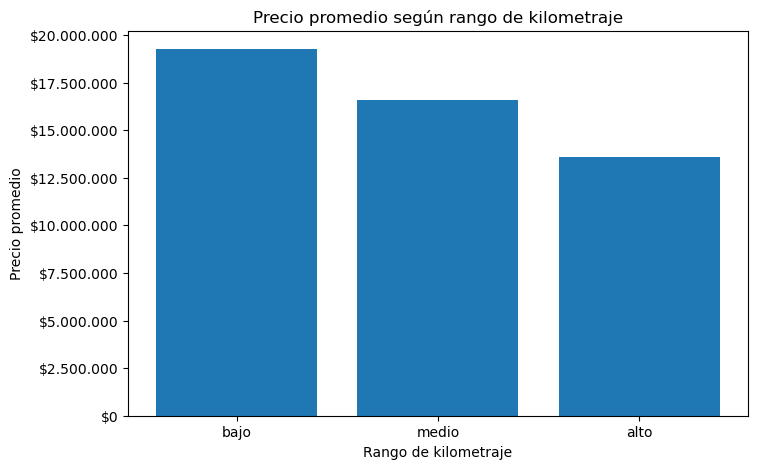

In [7]:
rango_grafico = df_rango.toPandas()

plt.figure(figsize=(8, 5))

plt.bar(
    rango_grafico["rango_kilometraje"],
    rango_grafico["precio_promedio"]
)

plt.title("Precio promedio según rango de kilometraje")
plt.xlabel("Rango de kilometraje")
plt.ylabel("Precio promedio")
formato_pesos_eje()

plt.show()

## Interpretación de categoría de precio y rango de kilometraje

La categoría de precio permite observar cómo se distribuyen los vehículos entre segmentos bajos, medios, altos y premium. Esta etiqueta es útil porque ayuda a comprender que el mercado analizado no es homogéneo, sino que está compuesto por vehículos de distintos niveles comerciales.

El rango de kilometraje permite analizar el efecto del uso acumulado sobre el precio. Los vehículos con menor kilometraje tienden a presentar precios promedio más altos, mientras que aquellos con mayor kilometraje suelen concentrarse en valores menores.

Ambas variables ayudan a explicar la depreciación desde dos perspectivas: el valor comercial del vehículo y el desgaste asociado al uso.

In [8]:
df_marca = (
    df_eda.groupBy("marca")
    .agg(
        count("*").alias("cantidad"),
        spark_round(avg("precio"), 0).alias("precio_promedio"),
        spark_round(avg("kilometraje"), 0).alias("kilometraje_promedio"),
        spark_round(avg("antiguedad_auto"), 0).alias("antiguedad_promedio")
    )
    .filter(col("cantidad") >= 10)
    .orderBy(desc("precio_promedio"))
    .limit(10)
)

marca_pd = df_marca.toPandas()

for c in marca_pd.columns:
    if c != "marca":
        marca_pd[c] = marca_pd[c].apply(formato_chileno)

marca_pd

,marca,cantidad,precio_promedio,kilometraje_promedio,antiguedad_promedio
0,lexus,10,32.471.000,85.743,5
1,bmw,41,31.775.854,75.431,7
2,mercedes,25,30.614.400,89.513,8
3,audi,38,29.957.105,61.728,5
4,ford,174,24.979.799,73.605,5
5,subaru,38,20.130.000,82.175,5
6,toyota,131,19.984.007,74.372,4
7,mazda,48,19.541.458,79.089,6
8,volvo,15,18.732.667,104.674,9
9,jeep,33,17.277.879,94.104,7


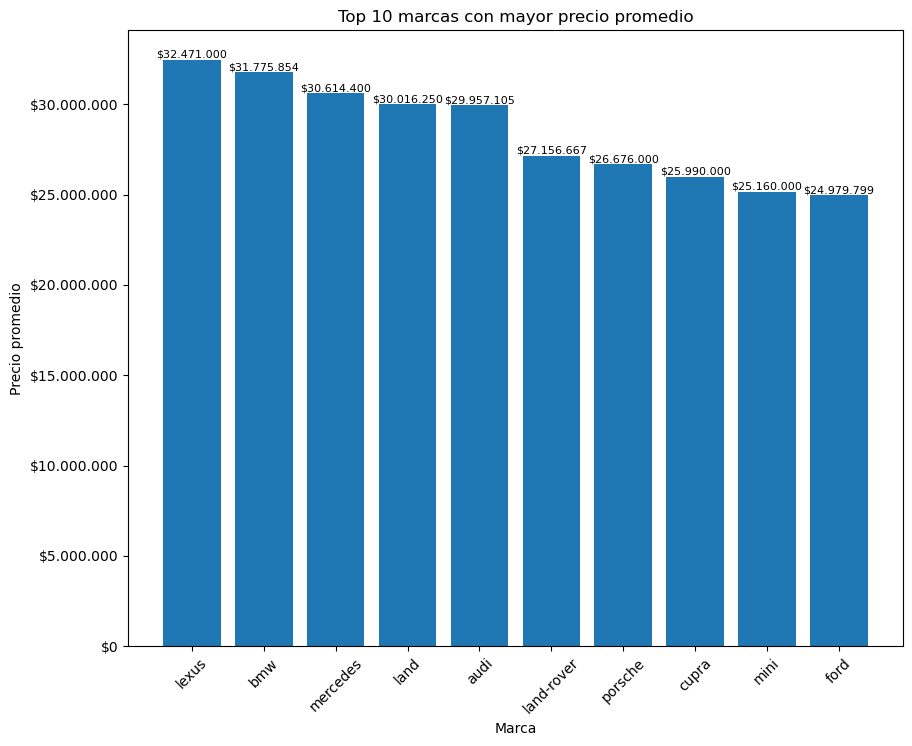

In [9]:
from pyspark.sql.functions import avg

df_marca = (
    df_eda.groupBy("marca")
    .agg(avg("precio").alias("precio_promedio"))
    .orderBy(col("precio_promedio").desc())
)

marca_pd = df_marca.limit(10).toPandas()

plt.figure(figsize=(10,8))

plt.bar(
    marca_pd["marca"],
    marca_pd["precio_promedio"]
)

plt.title("Top 10 marcas con mayor precio promedio")
plt.xlabel("Marca")
plt.ylabel("Precio promedio")

plt.xticks(rotation=45)

plt.ticklabel_format(style='plain', axis='y')
formato_pesos_eje()

for i, v in enumerate(marca_pd["precio_promedio"]):
    plt.text(
        i,
        v,
        f"${v:,.0f}".replace(",", "."),
        ha="center",
        va="bottom",
        fontsize=8
    )
plt.show()

## Interpretación del precio promedio por marca

El gráfico muestra las 10 marcas con mayor precio promedio dentro de la base de datos analizada. Se observa que Lexus, BMW, Mercedes y Audi lideran el ranking, con valores que superan los 29 millones de pesos en promedio.

Estos resultados reflejan el posicionamiento de estas marcas dentro del segmento premium, donde los vehículos suelen incorporar mayores niveles de tecnología, equipamiento, seguridad y prestaciones, factores que influyen directamente en su valor de mercado.

También se aprecia la presencia de marcas como Porsche, Land Rover, Mini y Cupra, que mantienen precios promedio elevados debido a su orientación hacia segmentos de mayor valor agregado y especialización.

Por otra parte, Ford aparece dentro de las diez marcas con mayor precio promedio principalmente por la presencia de modelos de alto valor comercial dentro de la base analizada. Esto demuestra que el precio no depende únicamente de la marca, sino también de la composición de los modelos disponibles en cada categoría.

En conjunto, el análisis confirma que la marca constituye un factor relevante en la valorización de los vehículos usados, generando diferencias significativas incluso entre automóviles con niveles similares de antigüedad y kilometraje.

In [10]:
df_tipo_marca = (
    df_eda.groupBy("tipo_marca")
    .agg(
        count("*").alias("cantidad"),
        spark_round(avg("precio"), 0).alias("precio_promedio"),
        spark_round(avg("kilometraje"), 0).alias("kilometraje_promedio"),
        spark_round(avg("antiguedad_auto"), 0).alias("antiguedad_promedio")
    )
    .orderBy(desc("precio_promedio"))
)

tipo_marca_pd = df_tipo_marca.toPandas()

for c in tipo_marca_pd.columns:
    if c != "tipo_marca":
        tipo_marca_pd[c] = tipo_marca_pd[c].apply(formato_chileno)

tipo_marca_pd

,tipo_marca,cantidad,precio_promedio,kilometraje_promedio,antiguedad_promedio
0,premium,122,30.705.738,76.206,7
1,general,1.866,15.518.591,70.734,5


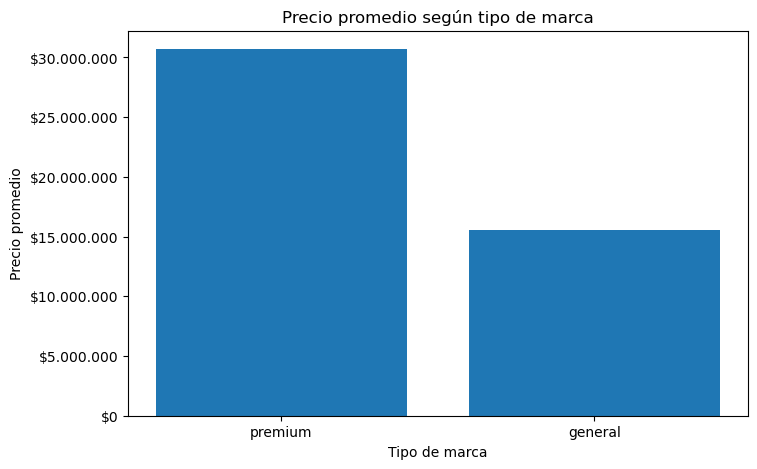

In [11]:
tipo_marca_grafico = df_tipo_marca.toPandas()

plt.figure(figsize=(8, 5))

plt.bar(
    tipo_marca_grafico["tipo_marca"],
    tipo_marca_grafico["precio_promedio"]
)

plt.title("Precio promedio según tipo de marca")
plt.xlabel("Tipo de marca")
plt.ylabel("Precio promedio")
formato_pesos_eje()

plt.show()

## Interpretación del efecto de la marca

El análisis por tipo de marca muestra diferencias significativas en los precios promedio de los vehículos presentes en la base de datos. Los vehículos clasificados como marcas premium alcanzan un precio promedio cercano a los 30 millones, mientras que los vehículos de marcas generalistas presentan un promedio cercano a los 15 millones.

Esta diferencia sugiere que el posicionamiento de marca influye directamente en el valor de mercado de los vehículos usados. Las marcas premium suelen ofrecer mayores niveles de equipamiento, tecnología, seguridad y prestaciones, características que contribuyen a mantener un mayor valor comercial incluso después de varios años de uso.

Además, los resultados evidencian que vehículos con niveles similares de antigüedad y kilometraje pueden presentar diferencias importantes de precio dependiendo de la categoría de marca a la que pertenezcan. Esto confirma que la marca constituye un factor relevante en la valorización de los vehículos dentro del mercado automotriz.

In [12]:
df_segmento = (
    df_eda.groupBy("segmento_depreciacion")
    .agg(
        count("*").alias("cantidad"),
        spark_round(avg("precio"), 0).alias("precio_promedio"),
        spark_round(avg("kilometraje"), 0).alias("kilometraje_promedio"),
        spark_round(avg("antiguedad_auto"), 0).alias("antiguedad_promedio")
    )
    .orderBy("precio_promedio")
)

df_segmento_pd = df_segmento.toPandas()

for c in df_segmento_pd.columns:
    if c != "segmento_depreciacion":
        df_segmento_pd[c] = df_segmento_pd[c].apply(formato_chileno)

df_segmento_pd

,segmento_depreciacion,cantidad,precio_promedio,kilometraje_promedio,antiguedad_promedio
0,alta depreciacion,409,13.122.592,139.389,9
1,depreciacion media,929,16.167.576,72.761,5
2,baja depreciacion,650,18.949.188,25.664,2


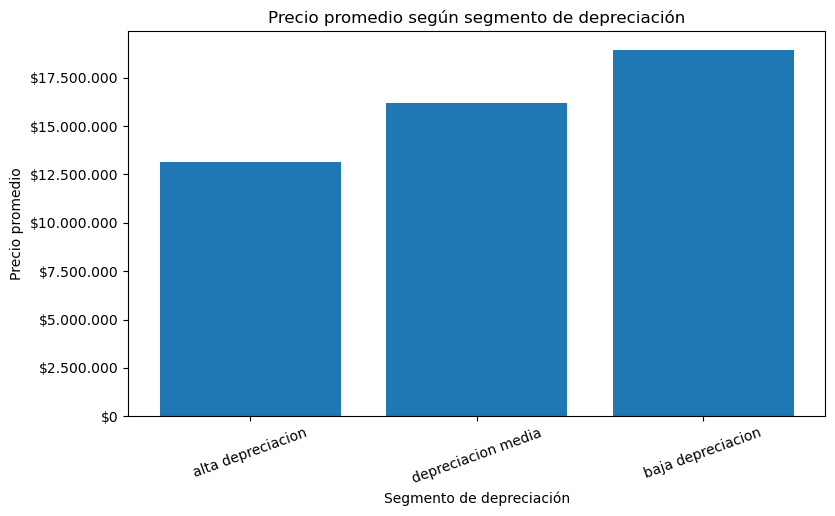

In [13]:
segmento_grafico = df_segmento.toPandas()

plt.figure(figsize=(9, 5))

plt.bar(
    segmento_grafico["segmento_depreciacion"],
    segmento_grafico["precio_promedio"]
)

plt.title("Precio promedio según segmento de depreciación")
plt.xlabel("Segmento de depreciación")
plt.ylabel("Precio promedio")
plt.xticks(rotation=20)
formato_pesos_eje()

plt.show()

## Interpretación del precio promedio por segmento

Los resultados muestran que los vehículos clasificados en baja depreciación presentan los precios promedio más altos, mientras que aquellos ubicados en alta depreciación registran valores menores.

Esto confirma que la pérdida acumulada de valor asociada al uso y antigüedad tiene un efecto directo sobre el precio de mercado de los vehículos usados.

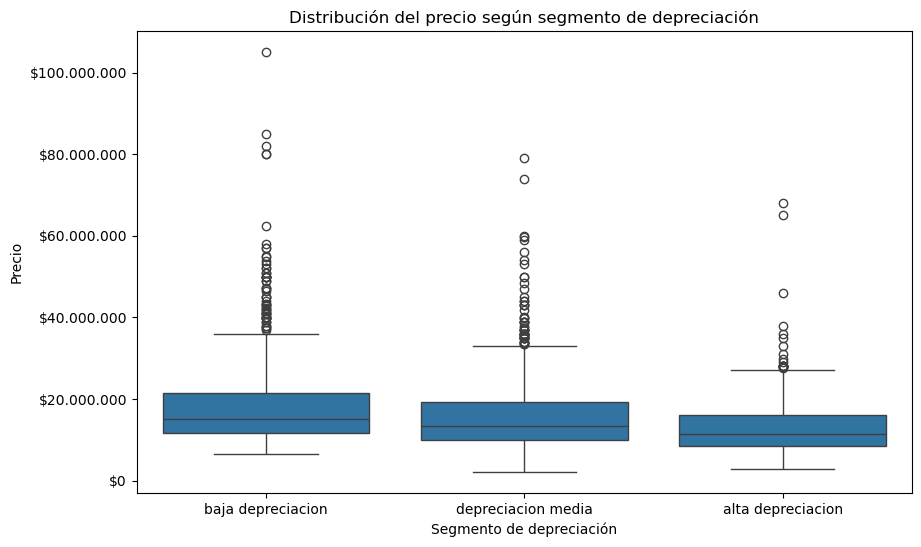

In [14]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_eda.toPandas(),
    x="segmento_depreciacion",
    y="precio"
)

plt.title("Distribución del precio según segmento de depreciación")
plt.xlabel("Segmento de depreciación")
plt.ylabel("Precio")
formato_pesos_eje()

plt.show()

## Interpretación del segmento de depreciación

El segmento de depreciación permite agrupar los vehículos según su nivel de uso y antigüedad. Los vehículos clasificados con baja depreciación presentan un precio promedio cercano a los 19 millones, mientras que los vehículos con alta depreciación alcanzan aproximadamente 13 millones. Esta diferencia confirma que la pérdida de valor acumulada tiene un impacto directo sobre el precio de mercado.

Por el contrario, los vehículos con alta depreciación concentran precios promedio menores, reflejando el efecto acumulado del tiempo y del uso sobre el valor de mercado.

El boxplot permite observar no sólo el promedio, sino también la dispersión de precios dentro de cada segmento. Esto es importante porque dentro de un mismo nivel de depreciación pueden existir vehículos con precios muy distintos, especialmente cuando intervienen marcas premium o modelos de mayor gama.

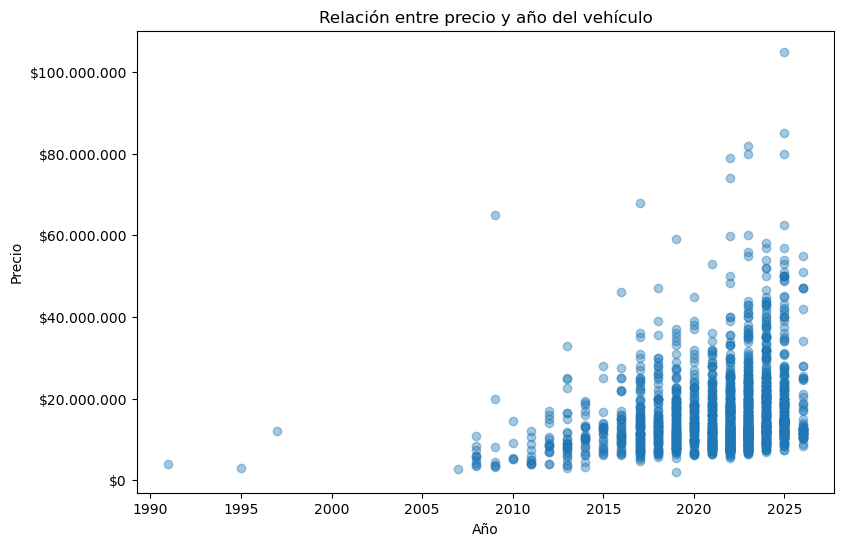

In [15]:
df_pd = df_eda.select(
    "precio",
    "kilometraje",
    "year",
    "antiguedad_auto"
).toPandas()

plt.figure(figsize=(9,6))

plt.scatter(
    df_pd["year"],
    df_pd["precio"],
    alpha=0.4
)

plt.title("Relación entre precio y año del vehículo")
plt.xlabel("Año")
plt.ylabel("Precio")

formato_pesos_eje()

plt.show()

## Interpretación de la relación entre precio y año del vehículo

El gráfico muestra una tendencia positiva entre el año de fabricación y el precio del vehículo. En general, los automóviles más recientes concentran los valores de mercado más altos, mientras que los modelos más antiguos presentan precios inferiores.

Esta relación es consistente con el proceso de depreciación vehicular, ya que los vehículos nuevos suelen incorporar tecnologías más modernas, mejores condiciones mecánicas y menor desgaste acumulado, factores que influyen directamente en su valorización comercial.

Sin embargo, también se observan diferencias de precio entre vehículos del mismo año de fabricación. Esto indica que el valor de mercado no depende únicamente de la fecha de fabricación, sino también de variables como la marca, el kilometraje, el tipo de combustible y el nivel de equipamiento.

Por esta razón, el año del vehículo constituye un factor relevante para explicar el precio, aunque debe analizarse de forma conjunta con otras características del mercado automotriz

In [16]:
df_combustible = (
    df_eda.groupBy("combustible")
    .agg(
        count("*").alias("cantidad"),
        spark_round(avg("precio"), 0).alias("precio_promedio"),
        spark_round(avg("kilometraje"), 0).alias("kilometraje_promedio"),
        spark_round(avg("antiguedad_auto"), 0).alias("antiguedad_promedio")
    )
    .orderBy(desc("precio_promedio"))
)

combustible_pd = df_combustible.toPandas()

for c in combustible_pd.columns:
    if c != "combustible":
        combustible_pd[c] = combustible_pd[c].apply(formato_chileno)

combustible_pd

,combustible,cantidad,precio_promedio,kilometraje_promedio,antiguedad_promedio
0,electrico,4,43.367.500,28.322,3
1,hibrido,22,27.019.091,33.177,2
2,diesel,468,16.736.436,95.319,5
3,bencina,1.494,16.133.365,64.146,5


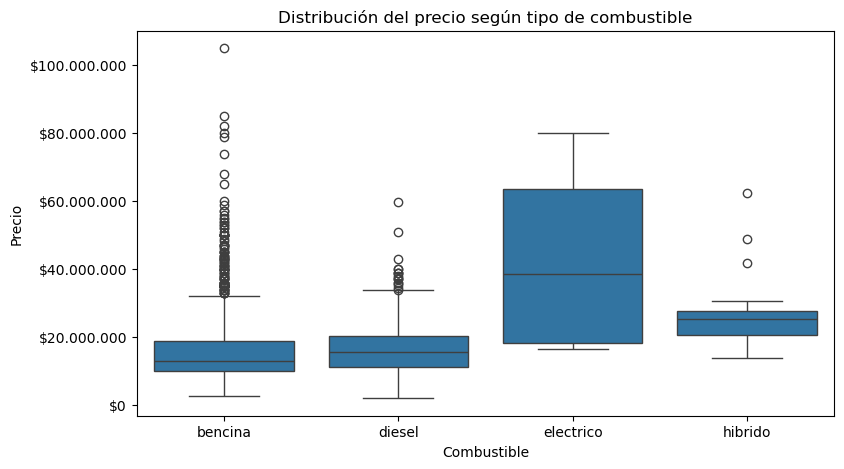

In [17]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_eda.toPandas(),
    x="combustible",
    y="precio"
)

plt.title("Distribución del precio según tipo de combustible")
plt.xlabel("Combustible")
plt.ylabel("Precio")
formato_pesos_eje()

plt.show()

## Interpretación del combustible
El análisis por tipo de combustible evidencia diferencias en los precios observados entre las distintas categorías de vehículos. Los vehículos eléctricos presentan los precios promedio más elevados, seguidos por los híbridos, mientras que los vehículos diésel y bencina concentran valores promedio más bajos dentro de la muestra analizada.

Esta diferencia puede estar asociada a que los vehículos eléctricos e híbridos corresponden generalmente a tecnologías más recientes, con mayores niveles de equipamiento y costos de adquisición superiores a los vehículos de combustión tradicional.

Sin embargo, estos resultados deben interpretarse con cautela debido a la baja cantidad de registros disponibles para vehículos eléctricos e híbridos dentro de la base de datos. Por esta razón, no es posible afirmar de manera concluyente que el combustible sea el principal determinante del precio, sino que su efecto debe analizarse en conjunto con variables como marca, antigüedad y kilometraje.

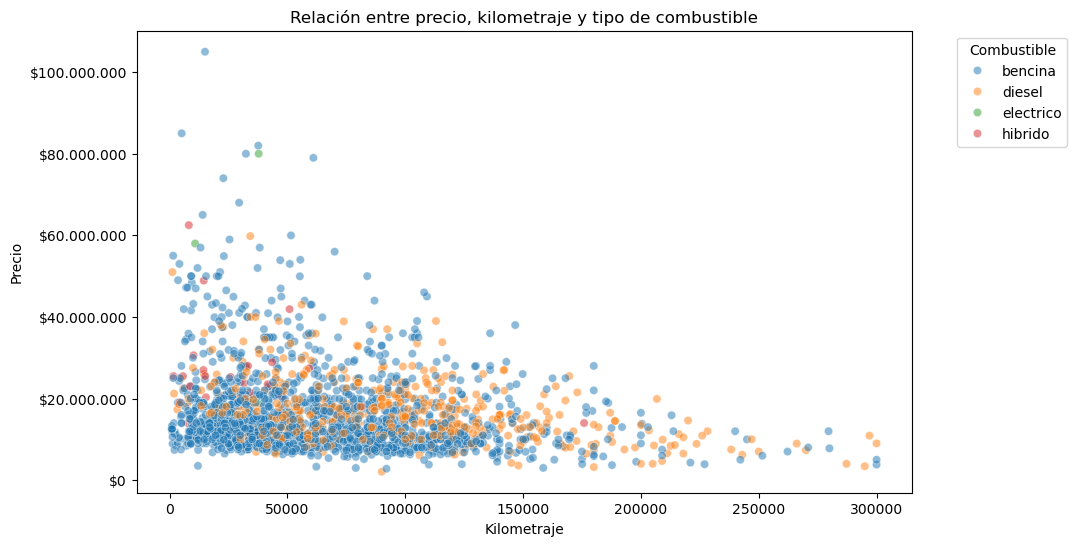

In [18]:
df_grafico_combustible = df_eda.select(
    "precio",
    "kilometraje",
    "combustible"
).toPandas()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_grafico_combustible,
    x="kilometraje",
    y="precio",
    hue="combustible",
    alpha=0.5
)

plt.title("Relación entre precio, kilometraje y tipo de combustible")
plt.xlabel("Kilometraje")
plt.ylabel("Precio")
formato_pesos_eje()

plt.legend(
    title="Combustible",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()

## Relación entre precio, kilometraje y combustible¶
Este gráfico permite observar cómo se comporta el precio frente al kilometraje considerando el tipo de combustible. En términos generales, los vehículos con mayor kilometraje tienden a presentar menores precios, independiente del combustible utilizado.

También se observa que algunos combustibles, como eléctrico o híbrido, pueden concentrarse en rangos de precio más altos, aunque con menor cantidad de registros. Esto sugiere que el combustible puede influir en el valor, pero su efecto debe analizarse junto con otras variables como año, marca y kilometraje.

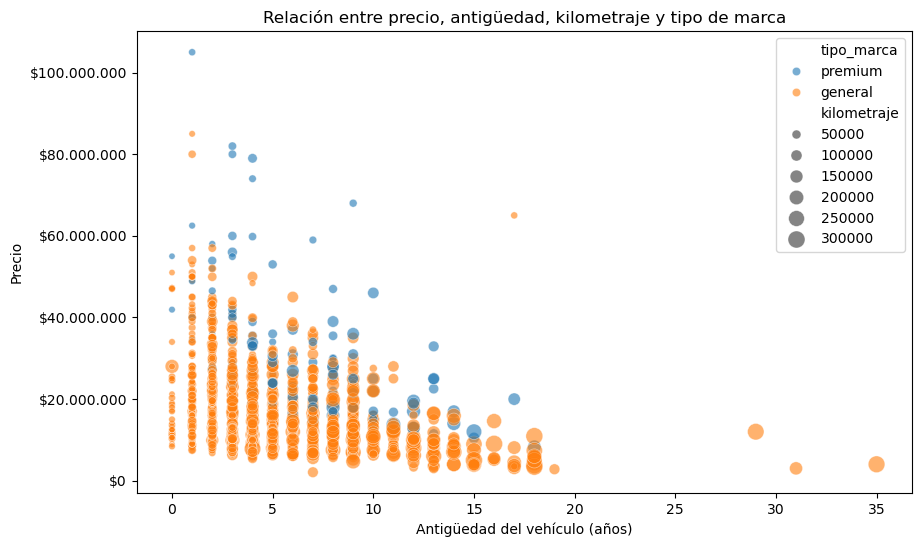

In [19]:
df_grafico_multi = df_eda.select(
    "precio",
    "antiguedad_auto",
    "tipo_marca",
    "kilometraje"
).toPandas()

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_grafico_multi,
    x="antiguedad_auto",
    y="precio",
    hue="tipo_marca",
    size="kilometraje",
    sizes=(20,150),
    alpha=0.6
)

plt.title("Relación entre precio, antigüedad, kilometraje y tipo de marca")
plt.xlabel("Antigüedad del vehículo (años)")
plt.ylabel("Precio")

formato_pesos_eje()

plt.show()

### Interpretación del análisis multivariado

El gráfico permite observar simultáneamente el efecto de la antigüedad, el kilometraje y el tipo de marca sobre el precio de los vehículos usados.

Se aprecia una relación negativa entre antigüedad y precio, ya que los vehículos más antiguos tienden a concentrarse en valores de mercado menores. Asimismo, los puntos de mayor tamaño, que representan un kilometraje más elevado, suelen ubicarse en zonas de menor precio, reforzando el efecto de depreciación asociado al uso.

También se observa que las marcas premium mantienen precios superiores a los de las marcas generales incluso cuando presentan niveles similares de antigüedad, lo que indica que la marca influye en la conservación del valor comercial.

En conjunto, los resultados sugieren que el precio de un vehículo no depende de una única variable, sino de la interacción entre antigüedad, kilometraje y posicionamiento de marca.

In [20]:
q1 = df_eda.approxQuantile("precio", [0.25], 0.01)[0]
q3 = df_eda.approxQuantile("precio", [0.75], 0.01)[0]
iqr = q3 - q1

limite_superior = q3 + 1.5 * iqr

anomalias_precio = df_eda.filter(col("precio") > limite_superior)

print("Límite superior de precio atípico:", f"${limite_superior:,.0f}".replace(",", "."))
print("Cantidad de posibles anomalías:", anomalias_precio.count())

anomalias_precio.select(
    "marca",
    "modelo_limpio",
    "precio",
    "kilometraje",
    "year",
    "combustible",
    "tipo_marca",
    "categoria_precio",
    "segmento_depreciacion"
).show(10, truncate=False)

Límite superior de precio atípico: $32.540.000
Cantidad de posibles anomalías: 134
+-----+----------------------------+-------+-----------+----+-----------+----------+----------------+---------------------+
|marca|modelo_limpio               |precio |kilometraje|year|combustible|tipo_marca|categoria_precio|segmento_depreciacion|
+-----+----------------------------+-------+-----------+----+-----------+----------+----------------+---------------------+
|audi |Q8 : 3.0 55 Tfsi Sline Quatt|5.599E7|70030.0    |2023|bencina    |premium   |premium         |depreciacion media   |
|audi |S4 3.0 Tfsi Tiptronic Quattr|5.199E7|11824.0    |2024|bencina    |premium   |premium         |baja depreciacion    |
|bmw  |X5 Xdrive 40 Msport         |5.997E7|51500.0    |2023|bencina    |premium   |premium         |depreciacion media   |
|audi |E-tron Bev 95kwh 55 Quattro |5.799E7|10808.0    |2024|electrico  |premium   |premium         |baja depreciacion    |
|audi |Q3 Sportback 1.4t 35 Tfsi S-|3.449E7|7018.

In [21]:
anomalias_marca = (
    anomalias_precio
    .groupBy("marca")
    .agg(count("*").alias("cantidad_anomalias"))
    .orderBy(desc("cantidad_anomalias"))
)

anomalias_marca.show(truncate=False)

+----------+------------------+
|marca     |cantidad_anomalias|
+----------+------------------+
|ford      |46                |
|bmw       |16                |
|chevrolet |15                |
|audi      |11                |
|mercedes  |9                 |
|toyota    |9                 |
|lexus     |5                 |
|mazda     |5                 |
|subaru    |4                 |
|jeep      |3                 |
|ram       |3                 |
|land      |3                 |
|land-rover|1                 |
|hyundai   |1                 |
|porsche   |1                 |
|volkswagen|1                 |
|nissan    |1                 |
+----------+------------------+



## Interpretación de anomalías

La detección de anomalías mediante el método IQR permitió identificar 134 vehículos con precios significativamente superiores al comportamiento general de la base de datos.

Al analizar estos registros, se observa la presencia de anomalías tanto en marcas premium como en marcas generalistas. Destacan Ford, BMW, Chevrolet y Audi como las marcas con mayor cantidad de registros identificados, lo que indica que los valores atípicos no dependen exclusivamente del segmento de marca, sino también de características particulares de determinados modelos.

En la mayoría de los casos, estas observaciones corresponden a vehículos recientes, con bajo kilometraje o versiones de mayor equipamiento y valor comercial. Por esta razón, no necesariamente representan errores de captura, sino vehículos que se encuentran en segmentos específicos del mercado con precios considerablemente superiores al promedio.

La identificación de estas anomalías resulta relevante para comprender la estructura de precios de la base analizada y para futuras etapas de modelamiento predictivo, donde podrían requerir un tratamiento especial con el fin de evitar sesgos en las estimaciones.

## Conclusión general de los gráficos de relaciones

Los gráficos de relaciones permitieron visualizar de manera conjunta el comportamiento de las principales variables asociadas al precio de los vehículos usados.

La relación entre precio y kilometraje evidenció una tendencia descendente, donde los vehículos con mayor nivel de uso tienden a presentar valores de mercado más bajos. De forma similar, la relación entre precio y año de fabricación mostró que los modelos más recientes concentran los precios más elevados, mientras que los vehículos más antiguos presentan una mayor depreciación.

Además, el análisis por tipo de combustible mostró diferencias entre categorías, aunque estas deben interpretarse con cautela debido al reducido número de registros disponibles para algunas tecnologías. Por su parte, la comparación entre marcas permitió observar que los vehículos premium mantienen valores superiores respecto de los vehículos generalistas.

Finalmente, el análisis multivariado confirmó que el precio de mercado no depende de una sola característica, sino de la combinación de factores como antigüedad, kilometraje, marca y combustible. Esto demuestra la complejidad del mercado automotriz y la necesidad de considerar múltiples variables para comprender adecuadamente la formación de precios.

## Conclusión general del EDA multivariado

Los resultados muestran que la antigüedad y el kilometraje mantienen una relación inversa con el precio, evidenciando el proceso natural de depreciación que experimentan los vehículos a medida que aumenta el uso y transcurre el tiempo.

Asimismo, variables como la marca, el tipo de combustible y el segmento de depreciación generan diferencias importantes en los valores de mercado. En particular, los vehículos pertenecientes a marcas premium presentan precios significativamente superiores a los de marcas generalistas, incluso bajo condiciones similares de antigüedad y kilometraje.

Por otra parte, se identificaron valores atípicos asociados principalmente a vehículos de alta gama y modelos con características especiales, lo que demuestra la existencia de segmentos específicos con comportamientos distintos al promedio de la muestra.

En conjunto, los resultados confirman que el precio de un vehículo usado depende de la interacción de múltiples variables y no de un único factor aislado. Esta información proporciona una base sólida para futuras etapas de análisis predictivo orientadas a estimar precios y comprender el comportamiento del mercado automotriz.